In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [8, 8]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 9600x9600 with 0 Axes>

<Figure size 9600x9600 with 0 Axes>

# bcd)

In [3]:
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"

testnpy = np.load("../{}/{}250/out.npz".format(root_dir, data_dir_prefix), allow_pickle=True)
op_pulse = np.load("../{}/{}250/out-op_pulse.npz".format(root_dir, data_dir_prefix), allow_pickle=True)

Omega1 = op_pulse['Omega1']
Omega2 = op_pulse['Omega2']
Delta1 = op_pulse['Delta1']
T_gate = op_pulse['T_gate']

Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
          'Delta1': Delta1, 
          'T_gate': T_gate}
times = np.linspace(0.0, T_gate, 100)

# Pulse shape
T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
n = 12   # Number of segments
dt = T_gate/n       # (mu s) Duration of each segment

def gaussian(t):
    # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
    t = t % T_gate
    t0 = T_gate/2
    tau = 0.165*T_gate
    a = np.exp(- t0**2 / tau**2)
    return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

pulse_Omega1 = []
pulse_Omega2 = []
pulse_Delta1 = []
for t in times:
    pulse_Omega1.append( gaussian(t))
    pulse_Omega2.append( Omega2[0] )
    pulse_Delta1.append( Delta1[0] )

# c)
out_init01_file = "../{}/{}250/out_init01.npz".format(root_dir, data_dir_prefix)
out_init01 = np.load(out_init01_file, allow_pickle=True)
print("out_init01.keys(): ", list(out_init01.keys()))

# d)
out_init11_file = "../{}/{}250/out_init11.npz".format(root_dir, data_dir_prefix)
out_init11 = np.load(out_init11_file, allow_pickle=True)
print("out_init11.keys(): ", list(out_init11.keys()))

out_init01.keys():  ['P01', 'P0p', 'P0r', 'P000d']
out_init11.keys():  ['P11', 'Ppp', 'P1rr1', 'Prr', 'P00dd']


# efg)

In [4]:
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"

testnpy = np.load("../{}/{}250_gammar44/out.npz".format(root_dir, data_dir_prefix), allow_pickle=True)
op_pulse_gammar44 = np.load("../{}/{}250_gammar44/out-op_pulse.npz".format(root_dir, data_dir_prefix), allow_pickle=True)

Omega1 = op_pulse_gammar44['Omega1']
Omega2 = op_pulse_gammar44['Omega2']
Delta1 = op_pulse_gammar44['Delta1']
T_gate = op_pulse_gammar44['T_gate']

Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
          'Delta1': Delta1, 
          'T_gate': T_gate}
times = np.linspace(0.0, T_gate, 100)

# Pulse shape
T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
T_gate_gammar44 = T_gate
n = 12   # Number of segments
dt = T_gate/n       # (mu s) Duration of each segment

def gaussian(t):
    # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
    t = t % T_gate
    t0 = T_gate/2
    tau = 0.165*T_gate
    a = np.exp(- t0**2 / tau**2)
    return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

pulse_Omega1_gammar44 = []
pulse_Omega2_gammar44 = []
pulse_Delta1_gammar44 = []
for t in times:
    pulse_Omega1_gammar44.append( gaussian(t))
    pulse_Omega2_gammar44.append( Omega2[0] )
    pulse_Delta1_gammar44.append( Delta1[0] )

# c)
out_init01_file = "../{}/{}250_gammar44/out_init01.npz".format(root_dir, data_dir_prefix)
out_init01_gammar44 = np.load(out_init01_file, allow_pickle=True)
print("out_init01.keys(): ", list(out_init01.keys()))

# d)
out_init11_file = "../{}/{}250_gammar44/out_init11.npz".format(root_dir, data_dir_prefix)
out_init11_gammar44 = np.load(out_init11_file, allow_pickle=True)
print("out_init11.keys(): ", list(out_init11.keys()))

out_init01.keys():  ['P01', 'P0p', 'P0r', 'P000d']
out_init11.keys():  ['P11', 'Ppp', 'P1rr1', 'Prr', 'P00dd']


# Plot

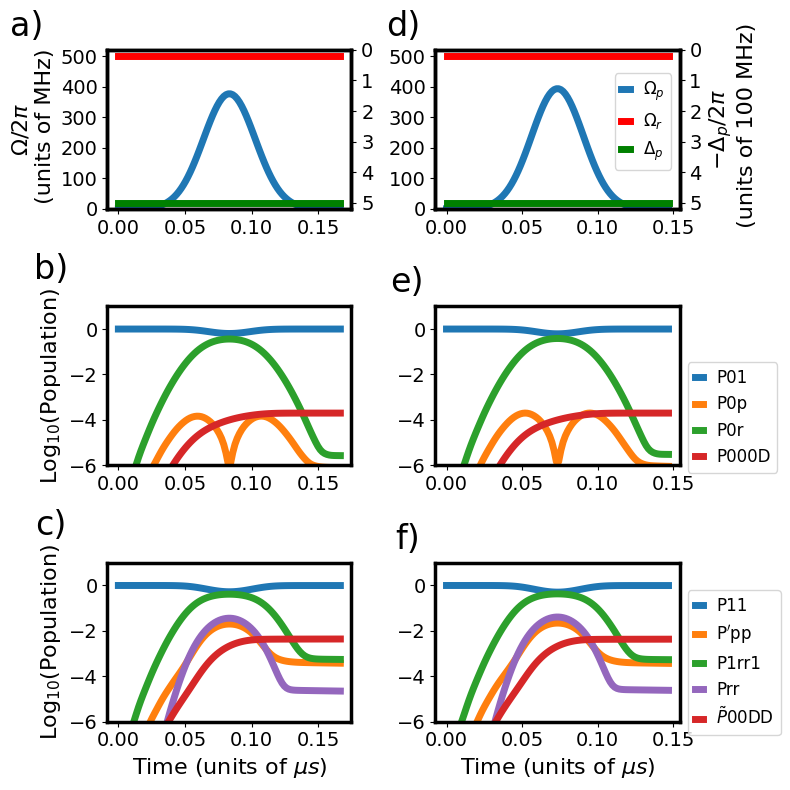

In [35]:
fig, axs = plt.subplots(3,2)

# axa = axs[0,0]
axb = axs[0, 0]
axc = axs[1, 0]
axd = axs[2, 0]
axe = axs[0, 1]
axf = axs[1, 1]
axg = axs[2, 1]

### 250
xinterval = np.arange(0, 0.17, 0.05)
T_gate = op_pulse['T_gate']
times = np.linspace(0.0, T_gate, 100)
#axb
axbp = axb.plot(times, pulse_Omega1, linewidth=5, label=r'$\Omega_p$')
axbp2 = axb.plot(times, pulse_Omega2, linewidth=5, label=r'$\Omega_r$', color='r')
axbt = axb.twinx()
axbtp = axbt.plot(times, [-x/100 for x in pulse_Delta1], linewidth=5, label=r'$\Delta_p$', color='g')
axbld = axbp + axbp2 + axbtp
axblb = [lb.get_label() for lb in axbld]
# axb.legend(axbld, axblb, bbox_to_anchor=(.676, .425), fontsize=10)

# axb.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12) 
axb.set_ylabel(r'$\Omega / 2 \pi$' '\n' ' (units of MHz)', fontsize=16)
# axbt.set_ylabel(r'$\Delta_p / 2 \pi$' ' (units of MHz)', fontsize=12)
axb.set_ylim(0, 520)
axbt.set_ylim(5.2, 0)

y1interval = np.arange(0, 600, 100)
y2interval = np.arange(5, -1, -1)
axb.set_xticks(xinterval)
axb.set_yticks(y1interval)
axbt.set_yticks(y2interval)
axb.tick_params(axis='both', labelsize=14)
axbt.tick_params(axis='y', rotation=0, labelsize=14)

axb.set_title('a)', x=-0.33, pad=10, fontsize=24)

#axc
axc.plot(times, out_init01["P01"], linewidth=5) 
axc.plot(times, out_init01["P0p"], linewidth=5)
axc.plot(times, out_init01["P0r"], linewidth=5)
axc.plot(times, out_init01["P000d"], linewidth=5)

# axc.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axc.set_ylim(-6, 1)
axc.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axc.legend(("P01", "P0p", "P0r", "P000D"), fontsize=10)

axc.set_xticks(xinterval)
axc.tick_params(axis='both', labelsize=14)

axc.set_title('b)', x=-0.23, pad=20, fontsize=24)

#axd
axd.plot(times, out_init11["P11"], linewidth=5) 
axd.plot(times, out_init11["Ppp"], linewidth=5)
axd.plot(times, out_init11["P1rr1"], linewidth=5)
axd.plot(times, out_init11["Prr"], linewidth=5, color='tab:purple')
axd.plot(times, out_init11["P00dd"], linewidth=5, color='tab:red')

axd.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axd.set_ylim(-6, 1)
axd.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=16) 
# axd.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), fontsize=10)

axd.set_xticks(xinterval)
axd.tick_params(axis='both', labelsize=14)

axd.set_title('c)', x=-0.23, pad=20, fontsize=24)


### 250_gammar44
T_gate = op_pulse_gammar44['T_gate']
times = np.linspace(0.0, T_gate_gammar44, 100)
xinterval = np.arange(0, 0.16, 0.05)

#axe
axep = axe.plot(times, pulse_Omega1_gammar44, linewidth=5, label=r'$\Omega_p$')
axep2 = axe.plot(times, pulse_Omega2_gammar44, linewidth=5, label=r'$\Omega_r$', color='r')
# axep2 = axe.hlines(y=Omega2[0], xmin=0, xmax=T_gate, linewidth=3.5, label=r'$\Omega_2$', color='r')
axet = axe.twinx()
axetp = axet.plot(times, [-x/100 for x in pulse_Delta1_gammar44], linewidth=5, label=r'$\Delta_p$', color='g')
axeld = axep + axep2 + axetp
axelb = [lb.get_label() for lb in axeld]
axe.legend(axeld, axelb, bbox_to_anchor=(.7, .55), fontsize=12, handlelength=0.5)

# axe.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12) 
# axe.set_ylabel(r'$\Omega / 2 \pi$' ' (units of MHz)', fontsize=12)
axet.set_ylabel(r'$-\Delta_p / 2 \pi$' '\n' ' (units of ' r'100' ' MHz)', fontsize=16)
axe.set_ylim(0, 520)
axet.set_ylim(5.2, 0)

y1interval = np.arange(0, 600, 100)
y2interval = np.arange(5, -1, -1)
axe.set_xticks(xinterval)
axe.set_yticks(y1interval)
axet.set_yticks(y2interval)
axe.tick_params(axis='both', labelsize=14)
axet.tick_params(axis='y', rotation=0, labelsize=14)

axe.set_title('d)', x=-0.13, pad=10, fontsize=24)

#axf
axf.plot(times, out_init01_gammar44["P01"], linewidth=5) 
axf.plot(times, out_init01_gammar44["P0p"], linewidth=5)
axf.plot(times, out_init01_gammar44["P0r"], linewidth=5)
axf.plot(times, out_init01_gammar44["P000d"], linewidth=5)

# axf.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axf.set_ylim(-6, 1)
# axf.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
axf.legend(("P01", "P0p", "P0r", "P000D"), bbox_to_anchor=(1., .7), fontsize=12, handlelength=0.5)

axf.set_xticks(xinterval)
axf.tick_params(axis='both', labelsize=14)

axf.set_title('e)', x=-0.115, pad=10, fontsize=24)

#axd
axg.plot(times, out_init11_gammar44["P11"], linewidth=5) 
axg.plot(times, out_init11_gammar44["Ppp"], linewidth=5)
axg.plot(times, out_init11_gammar44["P1rr1"], linewidth=5)
axg.plot(times, out_init11_gammar44["Prr"], linewidth=5, color='tab:purple')
axg.plot(times, out_init11_gammar44["P00dd"], linewidth=5, color='tab:red')

axg.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=16)
axg.set_ylim(-6, 1)
# axg.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
axg.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), bbox_to_anchor=(1., .88), fontsize=12, handlelength=0.5)

axg.set_xticks(xinterval)
axg.tick_params(axis='both', labelsize=14)

axg.set_title('f)', x=-0.115, pad=10, fontsize=24)


plt.savefig('fig1_500.eps', dpi=1200)